## Step 0 - Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))                       # so "from src.features import ..." works
PROCESSED_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reports" / "figures" / "m2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "Days for shipping (real)"
GROUP = "Order Id"
DATE_COL = "order date (DateOrders)"
DATE_FMT = "%m/%d/%Y %H:%M"

def show(fig, name):
    # Tidy, save for the report, and display
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.png", dpi=120)
    plt.show()

In [2]:
train = pd.read_csv(PROCESSED_DIR / "train_reg.csv")
train["order_dt"] = pd.to_datetime(train[DATE_COL], format=DATE_FMT)   # EDA helper column only, not a feature
y = train[TARGET]
print(f"Train: {train.shape[0]:,} rows, {train[GROUP].nunique():,} orders, {train.shape[1] - 1} original columns")
print(f"Order dates: {train['order_dt'].min()}  ->  {train['order_dt'].max()}")

Train: 138,098 rows, 50,318 orders, 28 original columns
Order dates: 2015-01-01 00:00:00  ->  2018-01-31 23:38:00


In [3]:
# 'Category Id' is a label code (1 code = 1 category), not a quantity, so it is not treated as numeric.
ID_CODES = ["Category Id"]

NUMERIC = [c for c in train.select_dtypes("number").columns if c not in (TARGET, GROUP, *ID_CODES)]
CATEGORICAL = [c for c in train.select_dtypes(exclude="number").columns if c not in (DATE_COL, "order_dt")]

structure = pd.DataFrame({
    "type": ["numeric" if c in NUMERIC else "categorical" for c in NUMERIC + CATEGORICAL],
    "n_unique": [train[c].nunique() for c in NUMERIC + CATEGORICAL],
    "example": [train[c].iloc[0] for c in NUMERIC + CATEGORICAL],
}, index=NUMERIC + CATEGORICAL)
structure

,type,n_unique,example
Benefit per order,numeric,20092,91.25
Sales per customer,numeric,2834,314.640015
Latitude,numeric,10480,18.251453
Longitude,numeric,4411,-66.037056
Order Item Discount,numeric,985,13.11
Order Item Discount Rate,numeric,18,0.04
Order Item Profit Ratio,numeric,162,0.29
Order Item Quantity,numeric,5,1
Sales,numeric,193,327.75
Product Price,numeric,75,327.75


In [4]:
train[NUMERIC].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Benefit per order,138098.0,22.17,103.76,-4274.98,7.14,31.67,64.89,911.80
Sales per customer,138098.0,183.29,119.97,7.49,104.38,163.99,247.50,1939.99
Latitude,138098.0,29.72,9.82,-33.94,18.27,33.15,39.28,48.78
Longitude,138098.0,-84.84,21.47,-158.03,-98.30,-76.77,-66.37,115.26
Order Item Discount,138098.0,20.67,21.88,0.00,5.40,14.00,30.00,500.00
Order Item Discount Rate,138098.0,0.10,0.07,0.00,0.04,0.09,0.16,0.25
Order Item Profit Ratio,138098.0,0.12,0.47,-2.75,0.08,0.27,0.36,0.50
Order Item Quantity,138098.0,2.13,1.45,1.00,1.00,1.00,3.00,5.00
Sales,138098.0,203.96,132.29,9.99,119.98,199.92,299.95,1999.99
Product Price,138098.0,141.44,139.84,9.99,50.00,65.00,199.99,1999.99


In [5]:
missing = train.isna().sum()
print("Columns with missing values:", missing[missing > 0].to_dict() or "none")
print("Exact duplicate rows:", train.duplicated().sum())

items = train.groupby(GROUP).size()
print(f"\nRows per order: mean {items.mean():.2f}, max {items.max()}, orders with >1 item {(items > 1).mean() * 100:.1f}%")

Columns with missing values: none
Exact duplicate rows: 0

Rows per order: mean 2.74, max 5, orders with >1 item 69.7%


count    138098.00
mean          3.50
std           1.63
min           0.00
25%           2.00
50%           3.00
75%           5.00
max           6.00
Name: Days for shipping (real), dtype: float64
Skewness: 0.09


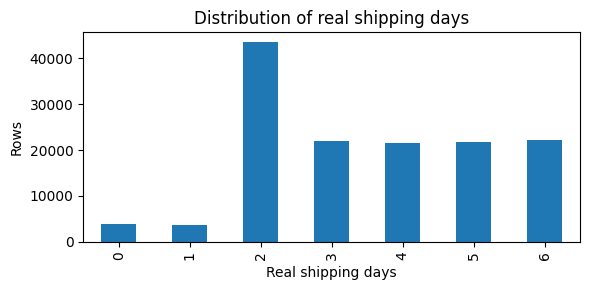

In [6]:
print(y.describe().round(2))
print(f"Skewness: {y.skew():.2f}")

fig, ax = plt.subplots(figsize=(6, 3))
y.value_counts().sort_index().plot.bar(ax=ax)
ax.set_xlabel("Real shipping days"); ax.set_ylabel("Rows"); ax.set_title("Distribution of real shipping days")
show(fig, "01_target_distribution")

                mean   std  min  max  count
Shipping Mode                              
Same Day        0.49  0.50    0    1   7431
First Class     2.00  0.00    2    2  21201
Second Class    3.99  1.42    2    6  26922
Standard Class  4.00  1.42    2    6  82544


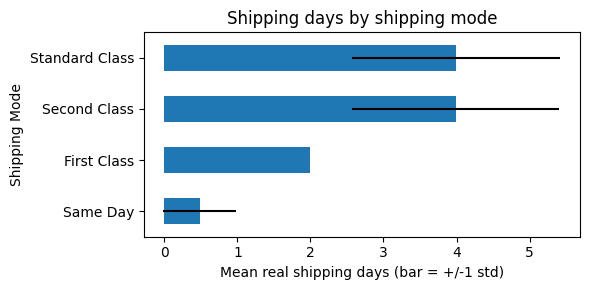

In [7]:
by_mode = train.groupby("Shipping Mode")[TARGET].agg(["mean", "std", "min", "max", "count"]).sort_values("mean")
print(by_mode.round(2))

fig, ax = plt.subplots(figsize=(6, 3))
by_mode["mean"].plot.barh(ax=ax, xerr=by_mode["std"])
ax.set_xlabel("Mean real shipping days (bar = +/-1 std)"); ax.set_title("Shipping days by shipping mode")
show(fig, "02_days_by_shipping_mode")

In [8]:
def eta_squared(cat, target):
    # Share of the target's variance explained by the category groups (0 = none, 1 = all)
    overall = target.mean()
    g = target.groupby(cat)
    ss_between = (g.size() * (g.mean() - overall) ** 2).sum()
    ss_total = ((target - overall) ** 2).sum()
    return ss_between / ss_total

cat_strength = pd.DataFrame({
    "n_categories": [train[c].nunique() for c in CATEGORICAL],
    "eta_squared": [eta_squared(train[c], y) for c in CATEGORICAL],
}, index=CATEGORICAL).sort_values("eta_squared", ascending=False)
cat_strength.round(4)

,n_categories,eta_squared
Shipping Mode,4,0.3889
Order City,3494,0.0964
Order State,1065,0.0295
Customer City,563,0.0130
Order Country,161,0.0043
Customer State,46,0.0013
Product Name,118,0.0010
Category Name,50,0.0005
Order Region,23,0.0004
Market,5,0.0001


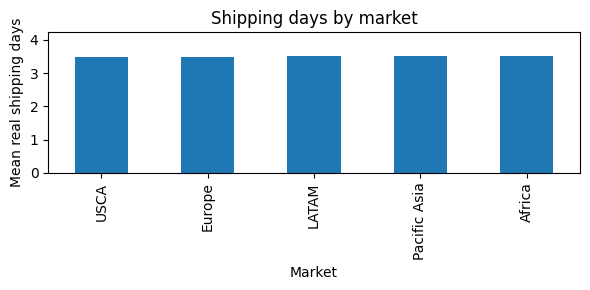

In [9]:
by_market = train.groupby("Market")[TARGET].mean().sort_values()
fig, ax = plt.subplots(figsize=(6, 3))
by_market.plot.bar(ax=ax)
ax.set_ylabel("Mean real shipping days"); ax.set_title("Shipping days by market")
ax.set_ylim(0, by_market.max() * 1.2)
show(fig, "03_days_by_market")

In [10]:
for col in ["Customer Segment", "Type", "Department Name"]:
    print(train.groupby(col)[TARGET].agg(["mean", "count"]).round(2), "\n")

                  mean  count
Customer Segment             
Consumer           3.5  71663
Corporate          3.5  41863
Home Office        3.5  24572 

          mean  count
Type                 
CASH      3.47  15622
DEBIT     3.49  55113
PAYMENT   3.52  33614
TRANSFER  3.50  33749 

                    mean  count
Department Name                
Apparel             3.50  37544
Book Shop           3.46    315
Discs Shop          3.58   1546
Fan Shop            3.50  51225
Fitness             3.52   1908
Footwear            3.50  11078
Golf                3.49  25321
Health and Beauty   3.45    273
Outdoors            3.53   7393
Pet Shop            3.34    375
Technology          3.40   1120 



In [11]:
num_vs_target = pd.DataFrame({
    "pearson": train[NUMERIC].corrwith(y),
    "spearman": train[NUMERIC].corrwith(y, method="spearman"),
}).sort_values("spearman", key=abs, ascending=False)
num_vs_target.round(3)

,pearson,spearman
Longitude,-0.003,-0.004
Order Item Discount Rate,0.002,0.002
Benefit per order,-0.003,-0.002
Sales per customer,0.001,-0.002
Order Item Quantity,-0.003,-0.002
Sales,0.001,-0.002
Order Item Profit Ratio,-0.003,-0.001
Order Item Discount,0.002,0.001
Product Price,0.002,-0.001
Latitude,-0.001,-0.000


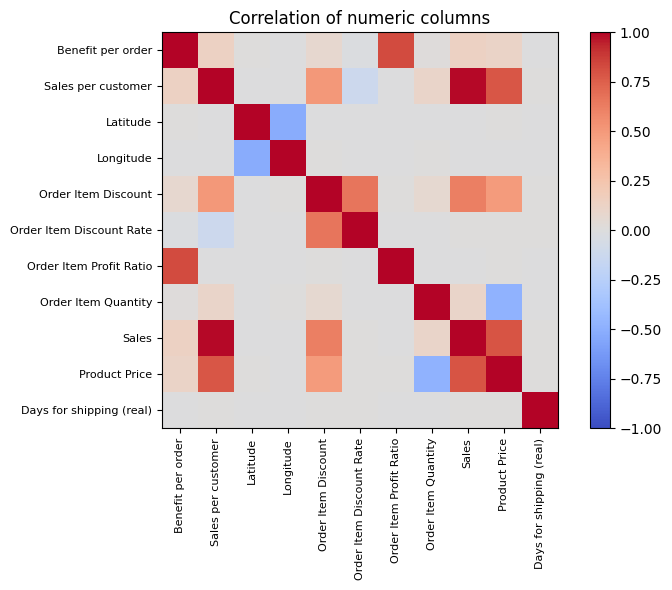

In [12]:
corr = train[NUMERIC + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
fig.colorbar(im, ax=ax); ax.set_title("Correlation of numeric columns")
show(fig, "04_correlation_heatmap")

In [13]:
pairs = corr.drop(index=TARGET, columns=TARGET).stack()
pairs = pairs[[a < b for a, b in pairs.index]]                # each pair once
high = pairs[pairs.abs() > 0.9].sort_values(key=abs, ascending=False)
print("Numeric pairs with |r| > 0.9:")
print(high.round(3) if len(high) else "none")

Numeric pairs with |r| > 0.9:
Sales  Sales per customer    0.99
dtype: float64


In [14]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean() * 100

outliers = pd.DataFrame({
    "outliers_%": [iqr_outliers(train[c]) for c in NUMERIC],
    "skew": [train[c].skew() for c in NUMERIC],
    "min": [train[c].min() for c in NUMERIC],
    "max": [train[c].max() for c in NUMERIC],
}, index=NUMERIC).sort_values("outliers_%", ascending=False)
outliers.round(2)

,outliers_%,skew,min,max
Benefit per order,10.40,-4.43,-4274.98,911.80
Order Item Profit Ratio,9.52,-2.91,-2.75,0.50
Order Item Discount,4.19,3.10,0.00,500.00
Product Price,1.13,3.18,9.99,1999.99
Sales per customer,1.07,2.87,7.49,1939.99
Longitude,0.77,-0.43,-158.03,115.26
Sales,0.27,2.88,9.99,1999.99
Latitude,0.01,-0.10,-33.94,48.78
Order Item Discount Rate,0.00,0.34,0.00,0.25
Order Item Quantity,0.00,0.88,1.00,5.00


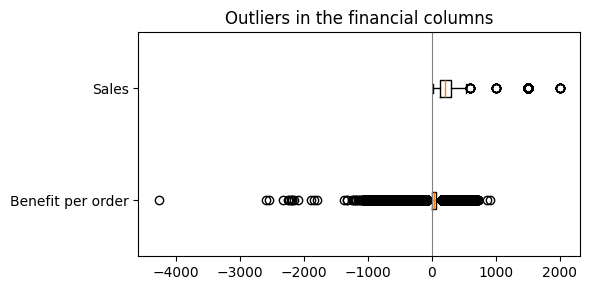

In [15]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.boxplot([train["Benefit per order"], train["Sales"]], vert=False)
ax.set_yticks([1, 2]); ax.set_yticklabels(["Benefit per order", "Sales"])
ax.axvline(0, color="grey", lw=0.8); ax.set_title("Outliers in the financial columns")
show(fig, "05_boxplot_financial")

In [16]:
neg = train["Benefit per order"] < 0
print(f"Rows with negative Benefit per order: {neg.mean() * 100:.1f}% (min {train['Benefit per order'].min():,.2f})")
print("Mean shipping days | profit < 0:", round(y[neg].mean(), 3), "| profit >= 0:", round(y[~neg].mean(), 3))

Rows with negative Benefit per order: 18.7% (min -4,274.98)
Mean shipping days | profit < 0: 3.508 | profit >= 0: 3.498


In [17]:
checks = {
    "Sales = Product Price x Quantity": np.isclose(train["Sales"], train["Product Price"] * train["Order Item Quantity"], atol=0.05),
    "Sales per customer = Sales - Discount": np.isclose(train["Sales per customer"], train["Sales"] - train["Order Item Discount"], atol=0.05),
    "Discount Rate = Discount / Sales": np.isclose(train["Order Item Discount Rate"], train["Order Item Discount"] / train["Sales"], atol=0.01),
    "Discount Rate between 0 and 1": train["Order Item Discount Rate"].between(0, 1),
}
pd.Series({k: f"{v.mean() * 100:.2f}% of rows" for k, v in checks.items()}, name="holds for")

Sales = Product Price x Quantity         100.00% of rows
Sales per customer = Sales - Discount    100.00% of rows
Discount Rate = Discount / Sales         100.00% of rows
Discount Rate between 0 and 1            100.00% of rows
Name: holds for, dtype: object

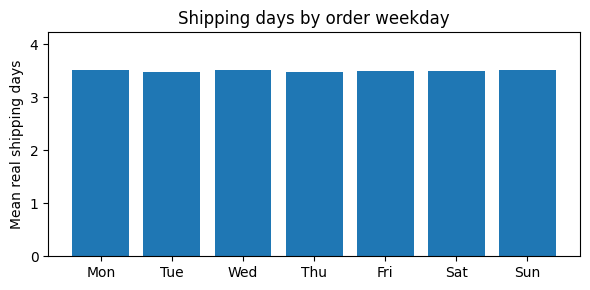

In [18]:
DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_weekday = y.groupby(train["order_dt"].dt.weekday).mean()
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar([DAYS[i] for i in by_weekday.index], by_weekday.values)
ax.set_ylabel("Mean real shipping days"); ax.set_title("Shipping days by order weekday")
ax.set_ylim(0, by_weekday.max() * 1.2)
show(fig, "06_days_by_weekday")

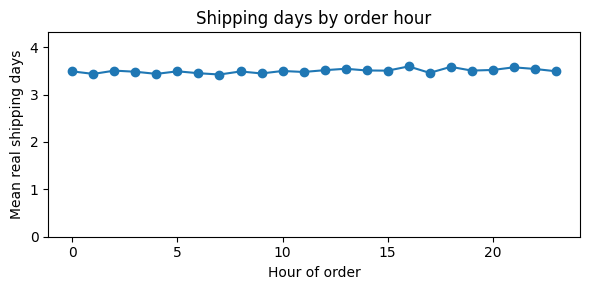

In [19]:
by_hour = y.groupby(train["order_dt"].dt.hour).mean()
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(by_hour.index, by_hour.values, marker="o")
ax.set_xlabel("Hour of order"); ax.set_ylabel("Mean real shipping days"); ax.set_title("Shipping days by order hour")
ax.set_ylim(0, by_hour.max() * 1.2)
show(fig, "07_days_by_hour")

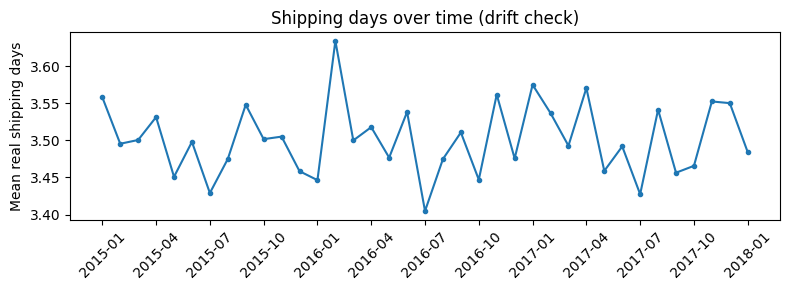

       mean_days   orders
count      37.00    37.00
mean        3.50  1359.95
std         0.05    95.96
min         3.40  1203.00
25%         3.47  1314.00
50%         3.50  1345.00
75%         3.54  1360.00
max         3.63  1630.00


In [20]:
monthly = train.groupby(train["order_dt"].dt.to_period("M")).agg(mean_days=(TARGET, "mean"), orders=(GROUP, "nunique"))
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(monthly.index.astype(str), monthly["mean_days"], marker=".")
ax.set_ylabel("Mean real shipping days"); ax.set_title("Shipping days over time (drift check)")
ax.set_xticks(range(0, len(monthly), max(1, len(monthly) // 12)))
ax.tick_params(axis="x", rotation=45)
show(fig, "08_days_over_time")
print(monthly.describe().round(2))

In [21]:
from src.features import DateFeatures, OrderFeatures, GeoFeatures

date_feats = DateFeatures().fit_transform(train)
order_feats = OrderFeatures().fit_transform(train)
parts = [date_feats, order_feats]

GEO_COLS = ["Customer Country", "Order Country"]
if all(c in train.columns for c in GEO_COLS):
    geo_feats = GeoFeatures().fit_transform(train)
    parts.append(geo_feats)
    print(f"is_domestic = 1 for {geo_feats['is_domestic'].mean() * 100:.1f}% of rows")
    print("Customer countries:", train["Customer Country"].unique())
    print("US / PR destinations:", [c for c in train["Order Country"].unique() if "Unidos" in c or "Puerto" in c])
else:
    print("Geo columns not present - GeoFeatures skipped")

engineered = pd.concat(parts, axis=1)
engineered.head()

is_domestic = 1 for 8.5% of rows
Customer countries: ['Puerto Rico' 'EE. UU.']
US / PR destinations: ['Estados Unidos', 'Emiratos Árabes Unidos']


,order_weekday,order_month,order_hour,order_quarter,is_weekend,order_items,order_total_sales,order_n_products,is_domestic
0,2,1,22,1,0,1,327.75,1,0
1,5,1,12,1,1,1,327.75,1,0
2,5,1,11,1,1,1,327.75,1,0
3,5,1,11,1,1,1,327.75,1,0
4,5,1,10,1,1,1,327.75,1,0


In [22]:
DISCRETE = [c for c in engineered.columns if engineered[c].nunique() <= 24]
CONTINUOUS = [c for c in engineered.columns if c not in DISCRETE]

eng_strength = pd.concat([
    pd.DataFrame({"measure": "eta_squared", "value": [eta_squared(engineered[c], y) for c in DISCRETE]}, index=DISCRETE),
    pd.DataFrame({"measure": "spearman", "value": [engineered[c].corr(y, method="spearman") for c in CONTINUOUS]}, index=CONTINUOUS),
])
eng_strength.round(4)

,measure,value
order_weekday,eta_squared,0.0001
order_month,eta_squared,0.0005
order_hour,eta_squared,0.0008
order_quarter,eta_squared,0.0001
is_weekend,eta_squared,0.0000
order_items,eta_squared,0.0000
order_n_products,eta_squared,0.0000
is_domestic,eta_squared,0.0000
order_total_sales,spearman,-0.0052


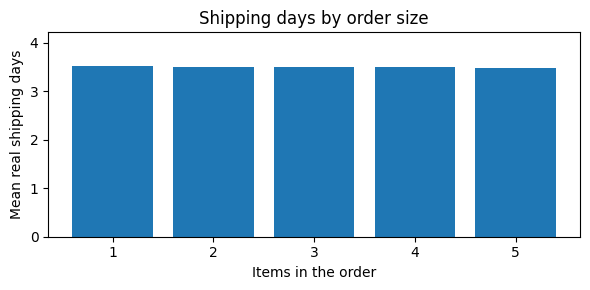

In [23]:
by_items = y.groupby(engineered["order_items"]).agg(["mean", "count"])
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(by_items.index.astype(str), by_items["mean"])
ax.set_xlabel("Items in the order"); ax.set_ylabel("Mean real shipping days"); ax.set_title("Shipping days by order size")
ax.set_ylim(0, by_items["mean"].max() * 1.2)
show(fig, "09_days_by_order_size")

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

test = pd.read_csv(PROCESSED_DIR / "test_reg.csv")
X_tr, X_te = train.drop(columns=[TARGET, "order_dt"]), test.drop(columns=[TARGET])
LOW_CARD = [c for c in CATEGORICAL if train[c].nunique() <= 30]

transformers = [
    ("num", SimpleImputer(strategy="median"), NUMERIC),                       # M4 adds scaling here
    ("low_card", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                           ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), LOW_CARD),  # M3
    ("date", Pipeline([("feats", DateFeatures()), ("impute", SimpleImputer(strategy="most_frequent"))]), [DATE_COL]),
    ("order", OrderFeatures(), [GROUP, "Sales", "Product Name"]),
]
if all(c in X_tr.columns for c in GEO_COLS):
    transformers.append(("geo", GeoFeatures(), GEO_COLS))

prep = ColumnTransformer(transformers, remainder="drop")
Xt_tr = prep.fit_transform(X_tr)      # fitted on TRAIN only
Xt_te = prep.transform(X_te)          # test is only transformed
print("Train matrix:", Xt_tr.shape, "| Test matrix:", Xt_te.shape)
print("Any missing values after preprocessing:", bool(np.isnan(Xt_tr).any() or np.isnan(Xt_te).any()))
print("Engineered columns:", [n for n in prep.get_feature_names_out() if n.split("__")[0] in ("date", "order", "geo")])

Train matrix: (138098, 71) | Test matrix: (34667, 71)
Any missing values after preprocessing: False
Engineered columns: ['date__order_weekday', 'date__order_month', 'date__order_hour', 'date__order_quarter', 'date__is_weekend', 'order__order_items', 'order__order_total_sales', 'order__order_n_products', 'geo__is_domestic']


In [25]:
# Pickle check: the backend must be able to load a pipeline that contains M2's classes
import pickle
pickle.loads(pickle.dumps(prep))
print("prep pickles and reloads OK")

prep pickles and reloads OK


In [26]:
top_cat = cat_strength.head(3)
top_num = num_vs_target.head(3)
findings = f'''
TARGET          mean {y.mean():.2f} days, std {y.std():.2f}, range {y.min()}-{y.max()}
SHIPPING MODE   eta^2 = {eta_squared(train["Shipping Mode"], y):.3f}  (share of variance explained by mode alone)
TOP CATEGORICAL {", ".join(f"{c} ({v:.3f})" for c, v in top_cat["eta_squared"].items())}
TOP NUMERIC     {", ".join(f"{c} ({v:+.3f})" for c, v in top_num["spearman"].items())}
REDUNDANT PAIRS {len(high)} numeric pairs with |r| > 0.9
OUTLIERS        highest share: {outliers.index[0]} ({outliers.iloc[0]["outliers_%"]:.1f}% of rows)
NEGATIVE PROFIT {neg.mean() * 100:.1f}% of rows (kept - genuine losses)
MISSING         {int(missing.sum())} missing cells | DUPLICATE ROWS {train.duplicated().sum()}
ENGINEERED      {", ".join(engineered.columns)}
'''
print(findings)
(ROOT / "reports" / "m2_findings.txt").write_text(findings, encoding="utf-8")


TARGET          mean 3.50 days, std 1.63, range 0-6
SHIPPING MODE   eta^2 = 0.389  (share of variance explained by mode alone)
TOP CATEGORICAL Shipping Mode (0.389), Order City (0.096), Order State (0.030)
TOP NUMERIC     Longitude (-0.004), Order Item Discount Rate (+0.002), Benefit per order (-0.002)
REDUNDANT PAIRS 1 numeric pairs with |r| > 0.9
OUTLIERS        highest share: Benefit per order (10.4% of rows)
NEGATIVE PROFIT 18.7% of rows (kept - genuine losses)
MISSING         0 missing cells | DUPLICATE ROWS 0
ENGINEERED      order_weekday, order_month, order_hour, order_quarter, is_weekend, order_items, order_total_sales, order_n_products, is_domestic



667